# CBA 2026 — Notebook 03: Headline performance

Aggregate prediction story for the CBA 2026 talk. Builds Figs P1–P4:

| Fig | What it shows |
| --- | --- |
| P1 | Headline grid: mean per-target Pearson r, R², pooled Pearson r, train_n by 3 variants × 2 frames × {TabPFN, RF}, faceted by family. |
| P2 | Per-target paired RF↔TabPFN scatter (CRISPR / drug). |
| P3 | ΔPearson r decomposition: distribution, cumulative win-rate, MOSA-only and model-only contributions. |
| P4 | Variant × frame heatmap of mean Pearson r and the matching train_n cohort-expansion bar. |

Outputs land at `reports/cba2026_claude/prediction_analysis/20260505_131645/` (composites) and `…/singles/` (single-panel slide cuts). All figure code lives in `_prediction_analysis.py`; this notebook is just the driver.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import _prediction_analysis as pred
from IPython.display import Image, display

print(f"ROOT     = {pred.ROOT}")
print(f"FIG_DIR  = {pred.FIG_DIR.relative_to(pred.ROOT)}")
print(f"SINGLE   = {pred.SINGLE_FIG_DIR.relative_to(pred.ROOT)}")

ROOT     = /mnt/scratch/scai/PhenPredCCMA
FIG_DIR  = reports/cba2026_claude/prediction_analysis/20260505_131645
SINGLE   = reports/cba2026_claude/prediction_analysis/20260505_131645/singles


## Load comparison frames

Three master tables drive every panel: a long-form summary (24 rows), a long-form per-target frame (~12k rows), and a per-target wide "decomposed" frame with the four headline levers.

In [2]:
summary_long = pred.load_summary_long()
per_target_long = pred.load_per_target_long()
decomposed = pred.load_decomposed()

print(f"summary_long    : {summary_long.shape}")
print(f"per_target_long : {per_target_long.shape}")
print(f"decomposed      : {decomposed.shape}")
summary_long.head(8)

summary_long    : (24, 20)
per_target_long : (12000, 11)
decomposed      : (1000, 37)


,experiment_name,target_family,sample_frame,variant,mosa_timestamp,tabpfn_estimator_mode,tabpfn_model_label,tabpfn_model_count,train_n,test_n,target_count,selected_feature_count,test_r2,test_pearsonr,test_rmse,pooled_test_pearsonr,pooled_test_rmse,test_observation_count,metric_aggregation,model_name
0,feature_augmentation,crisprcas9,overlap,original,20260505_131645,standard,tabpfn-v2.5-regressor-v2.5_default.ckpt,1.0,95,24,500,2000,-0.037483,0.143561,0.659954,0.746732,0.673153,11932,macro_mean_over_targets,tabpfn
1,feature_augmentation,crisprcas9,overlap,mosa_nan_only,20260505_131645,standard,tabpfn-v2.5-regressor-v2.5_default.ckpt,1.0,95,24,500,2000,-0.039472,0.143496,0.660491,0.746365,0.673575,11932,macro_mean_over_targets,tabpfn
2,feature_augmentation,crisprcas9,overlap,mosa_all,20260505_131645,standard,tabpfn-v2.5-regressor-v2.5_default.ckpt,1.0,95,24,500,2000,-0.024908,0.182190,0.655624,0.750464,0.668736,11932,macro_mean_over_targets,tabpfn
3,feature_augmentation,crisprcas9,expanded,original,20260505_131645,standard,tabpfn-v2.5-regressor-v2.5_default.ckpt,1.0,140,24,500,2000,-0.071330,0.153454,0.667639,0.741449,0.680883,11932,macro_mean_over_targets,tabpfn
4,feature_augmentation,crisprcas9,expanded,mosa_nan_only,20260505_131645,standard,tabpfn-v2.5-regressor-v2.5_default.ckpt,1.0,132,24,500,2000,-0.022602,0.168856,0.655464,0.750390,0.669125,11932,macro_mean_over_targets,tabpfn
5,feature_augmentation,crisprcas9,expanded,mosa_all,20260505_131645,standard,tabpfn-v2.5-regressor-v2.5_default.ckpt,1.0,132,24,500,2000,-0.001925,0.212351,0.648966,0.755551,0.662862,11932,macro_mean_over_targets,tabpfn
6,feature_augmentation,crisprcas9,overlap,original,20260505_131645,NaN,NaN,NaN,95,24,500,2000,-0.040316,0.151016,0.661047,0.745956,0.673725,11932,macro_mean_over_targets,random_forest
7,feature_augmentation,crisprcas9,overlap,mosa_nan_only,20260505_131645,NaN,NaN,NaN,95,24,500,2000,-0.039641,0.153304,0.660621,0.746491,0.673129,11932,macro_mean_over_targets,random_forest


## Sanity check — abstract numbers reproduce

Mean per-target Pearson r at TabPFN × expanded × MOSA(all) should be ≈ 0.21 (CRISPR) and ≈ 0.32 (drug); RF × overlap × original should be ≈ 0.15 (CRISPR) and ≈ 0.23 (drug).

In [3]:
import pandas as pd

checks = []
for family in pred.FAMILY_ORDER:
    for label, model, frame, variant in [
        ("abstract headline (TabPFN+MOSA)", "tabpfn",        "expanded", "mosa_all"),
        ("abstract baseline (RF+original)", "random_forest", "overlap",  "original"),
    ]:
        sub = per_target_long[
            (per_target_long["target_family"] == family)
            & (per_target_long["model_name"] == model)
            & (per_target_long["sample_frame"] == frame)
            & (per_target_long["variant"] == variant)
        ]
        m, lo, hi = pred.bootstrap_mean_ci(sub["test_pearsonr"].values)
        checks.append({
            "family": family, "condition": label,
            "mean_r": round(m, 3), "ci_lo": round(lo, 3), "ci_hi": round(hi, 3),
            "n": int((~sub["test_pearsonr"].isna()).sum()),
        })
pd.DataFrame(checks)

,family,condition,mean_r,ci_lo,ci_hi,n
0,crisprcas9,abstract headline (TabPFN+MOSA),0.212,0.191,0.233,500
1,crisprcas9,abstract baseline (RF+original),0.151,0.131,0.172,500
2,drugresponse,abstract headline (TabPFN+MOSA),0.319,0.297,0.341,500
3,drugresponse,abstract baseline (RF+original),0.235,0.213,0.256,500


## Figure P1 — headline performance grid

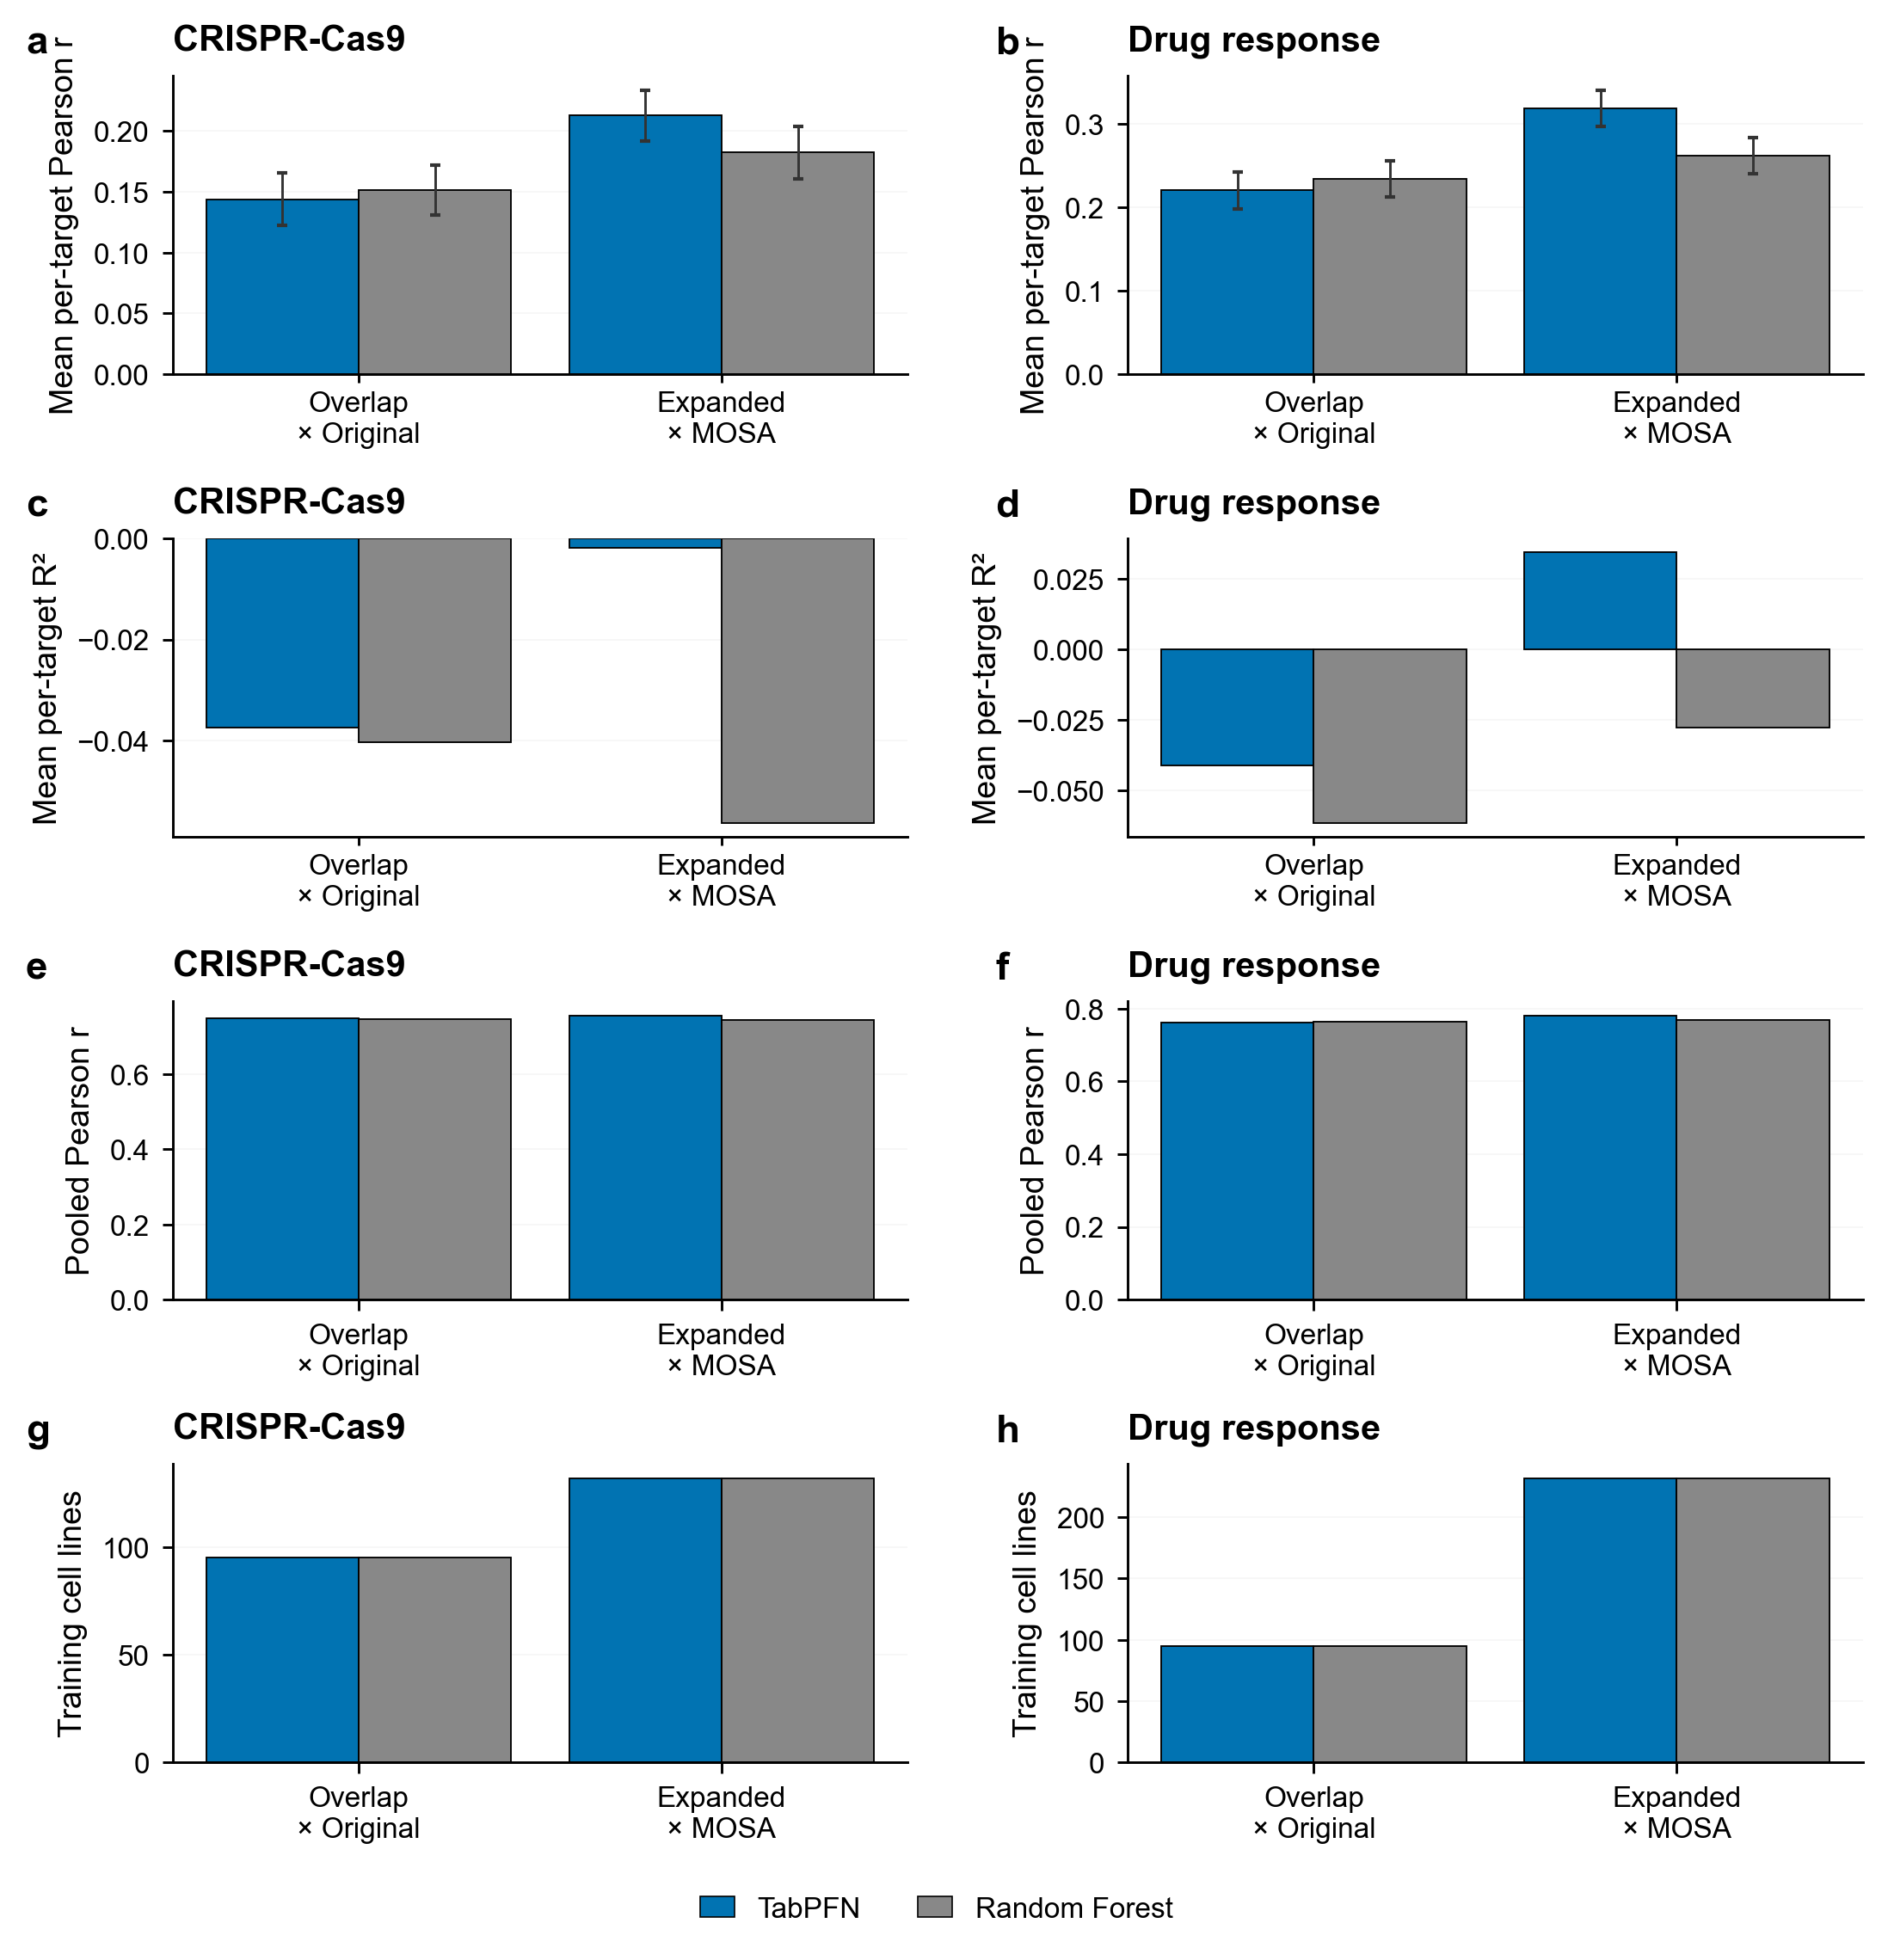

reports/cba2026_claude/prediction_analysis/20260505_131645/figP1_headline_performance.pdf


In [4]:
p1 = pred.figP1_headline_grid(summary_long, per_target_long)
display(Image(filename=str(p1.with_suffix(".png"))))
print(p1.relative_to(pred.ROOT))

## Figure P2 — paired per-target scatter

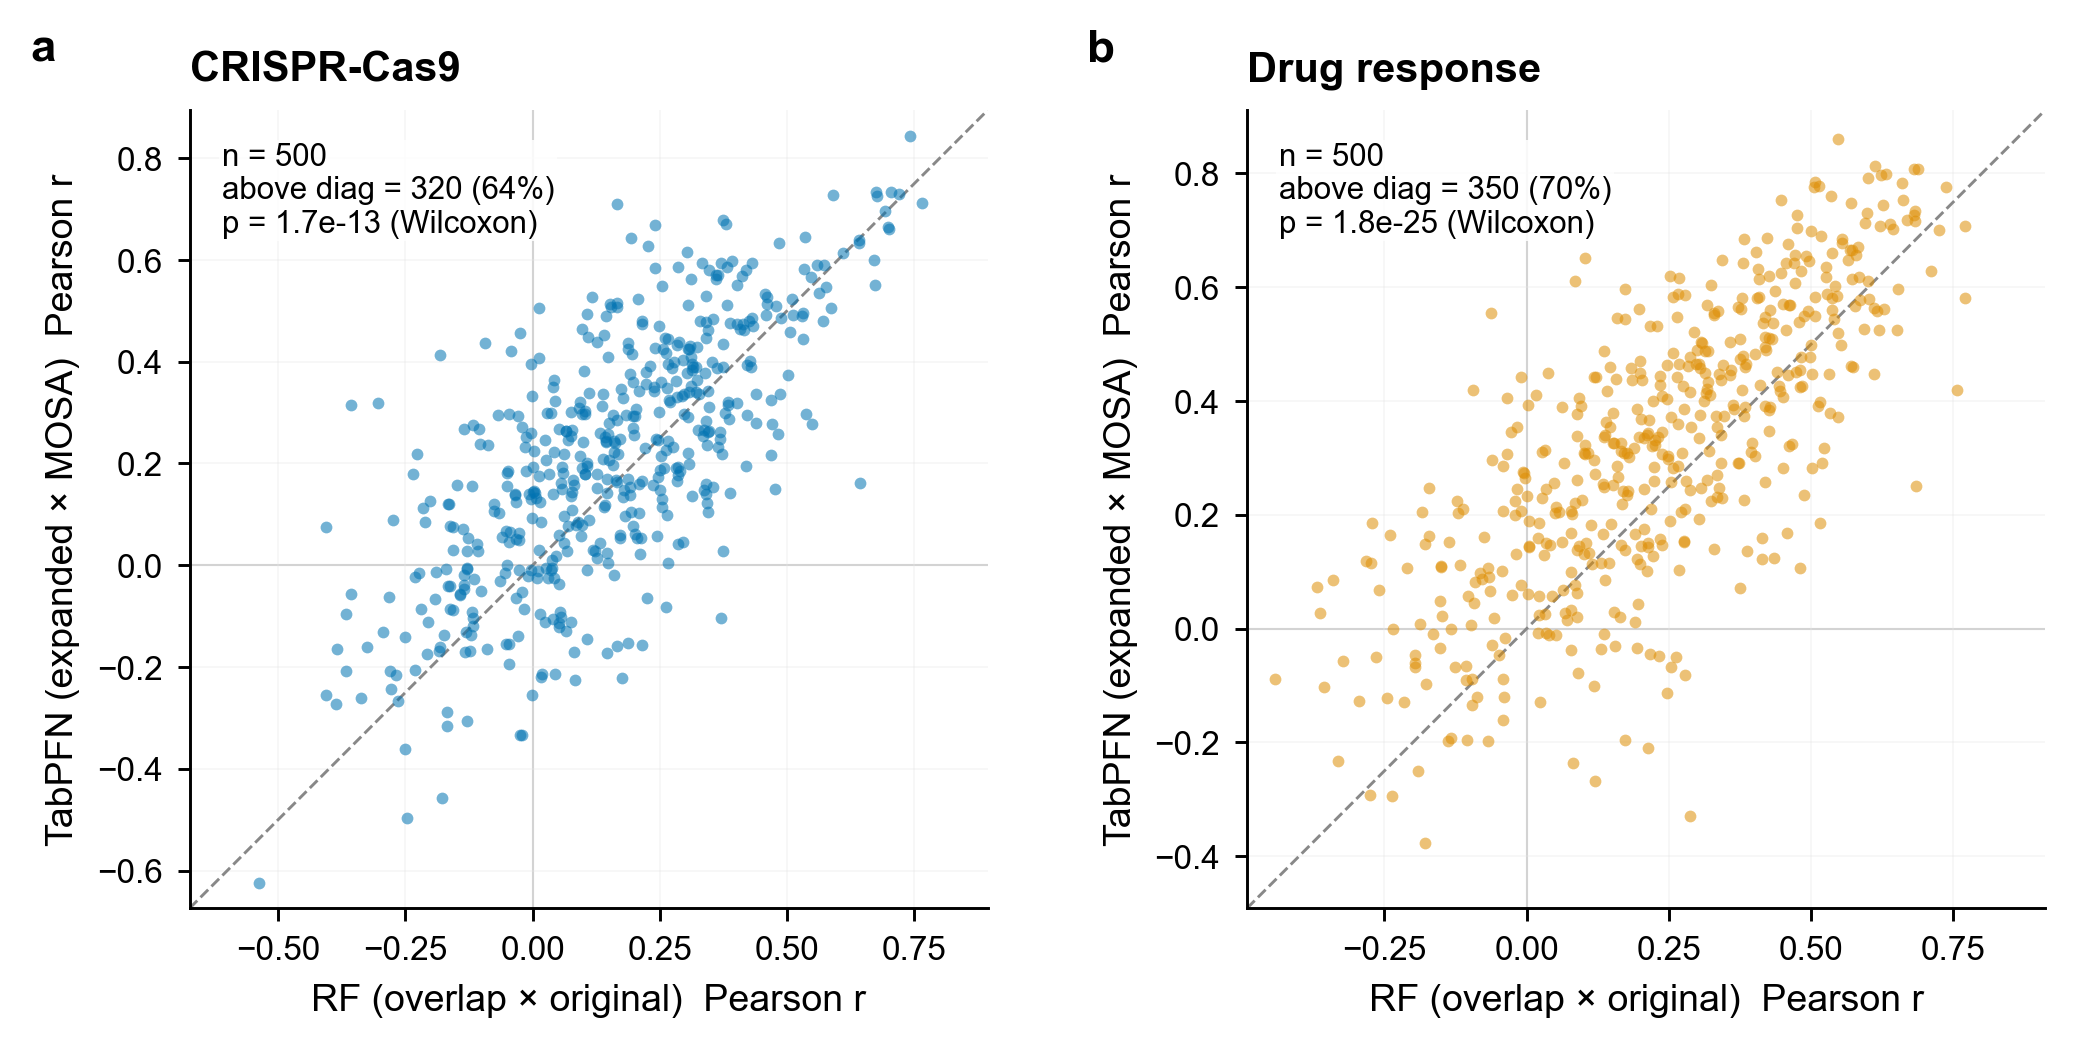

reports/cba2026_claude/prediction_analysis/20260505_131645/figP2_paired_scatter.pdf


In [5]:
p2 = pred.figP2_paired_scatter(decomposed)
display(Image(filename=str(p2.with_suffix(".png"))))
print(p2.relative_to(pred.ROOT))

## Figure P3 — ΔPearson r decomposition

Disentangles the headline gain into a model effect (RF → TabPFN) and a data effect (original → MOSA). Holding sample frame fixed at *expanded* keeps the comparison free of cohort-size confounds.

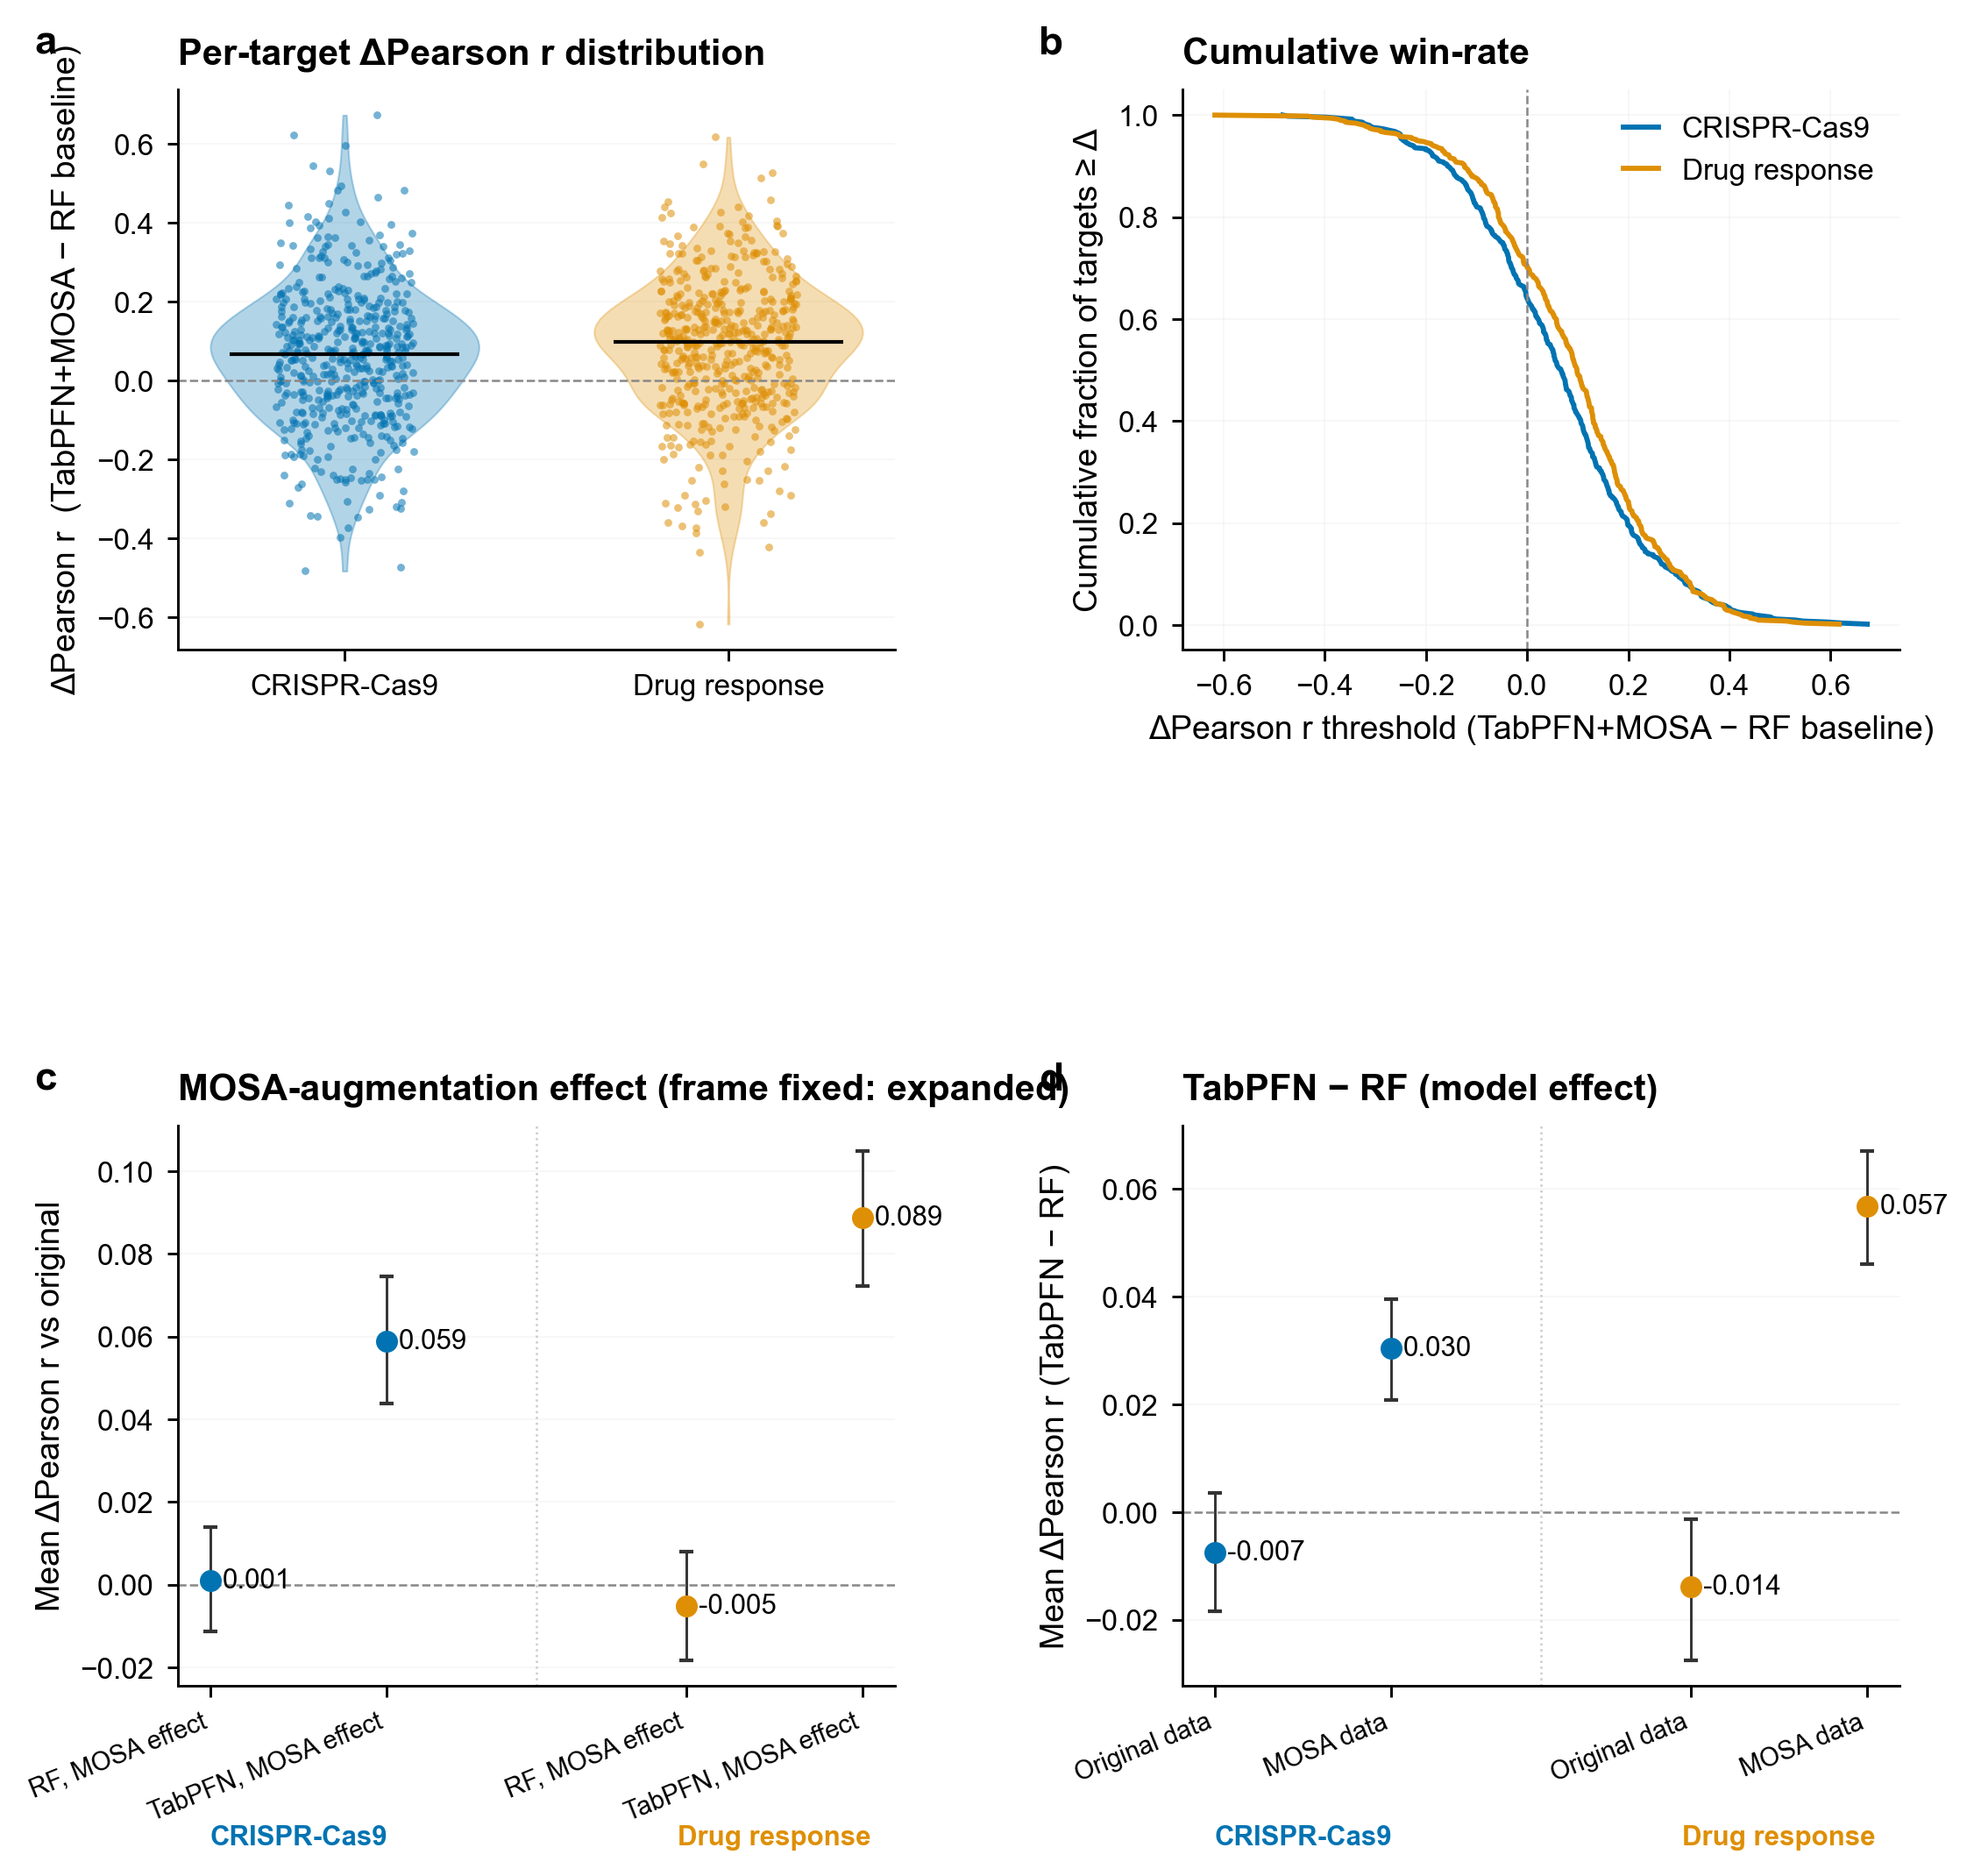

reports/cba2026_claude/prediction_analysis/20260505_131645/figP3_decomposition.pdf


In [6]:
p3 = pred.figP3_decomposition(decomposed)
display(Image(filename=str(p3.with_suffix(".png"))))
print(p3.relative_to(pred.ROOT))

## Figure P4 — strategy & sample frame

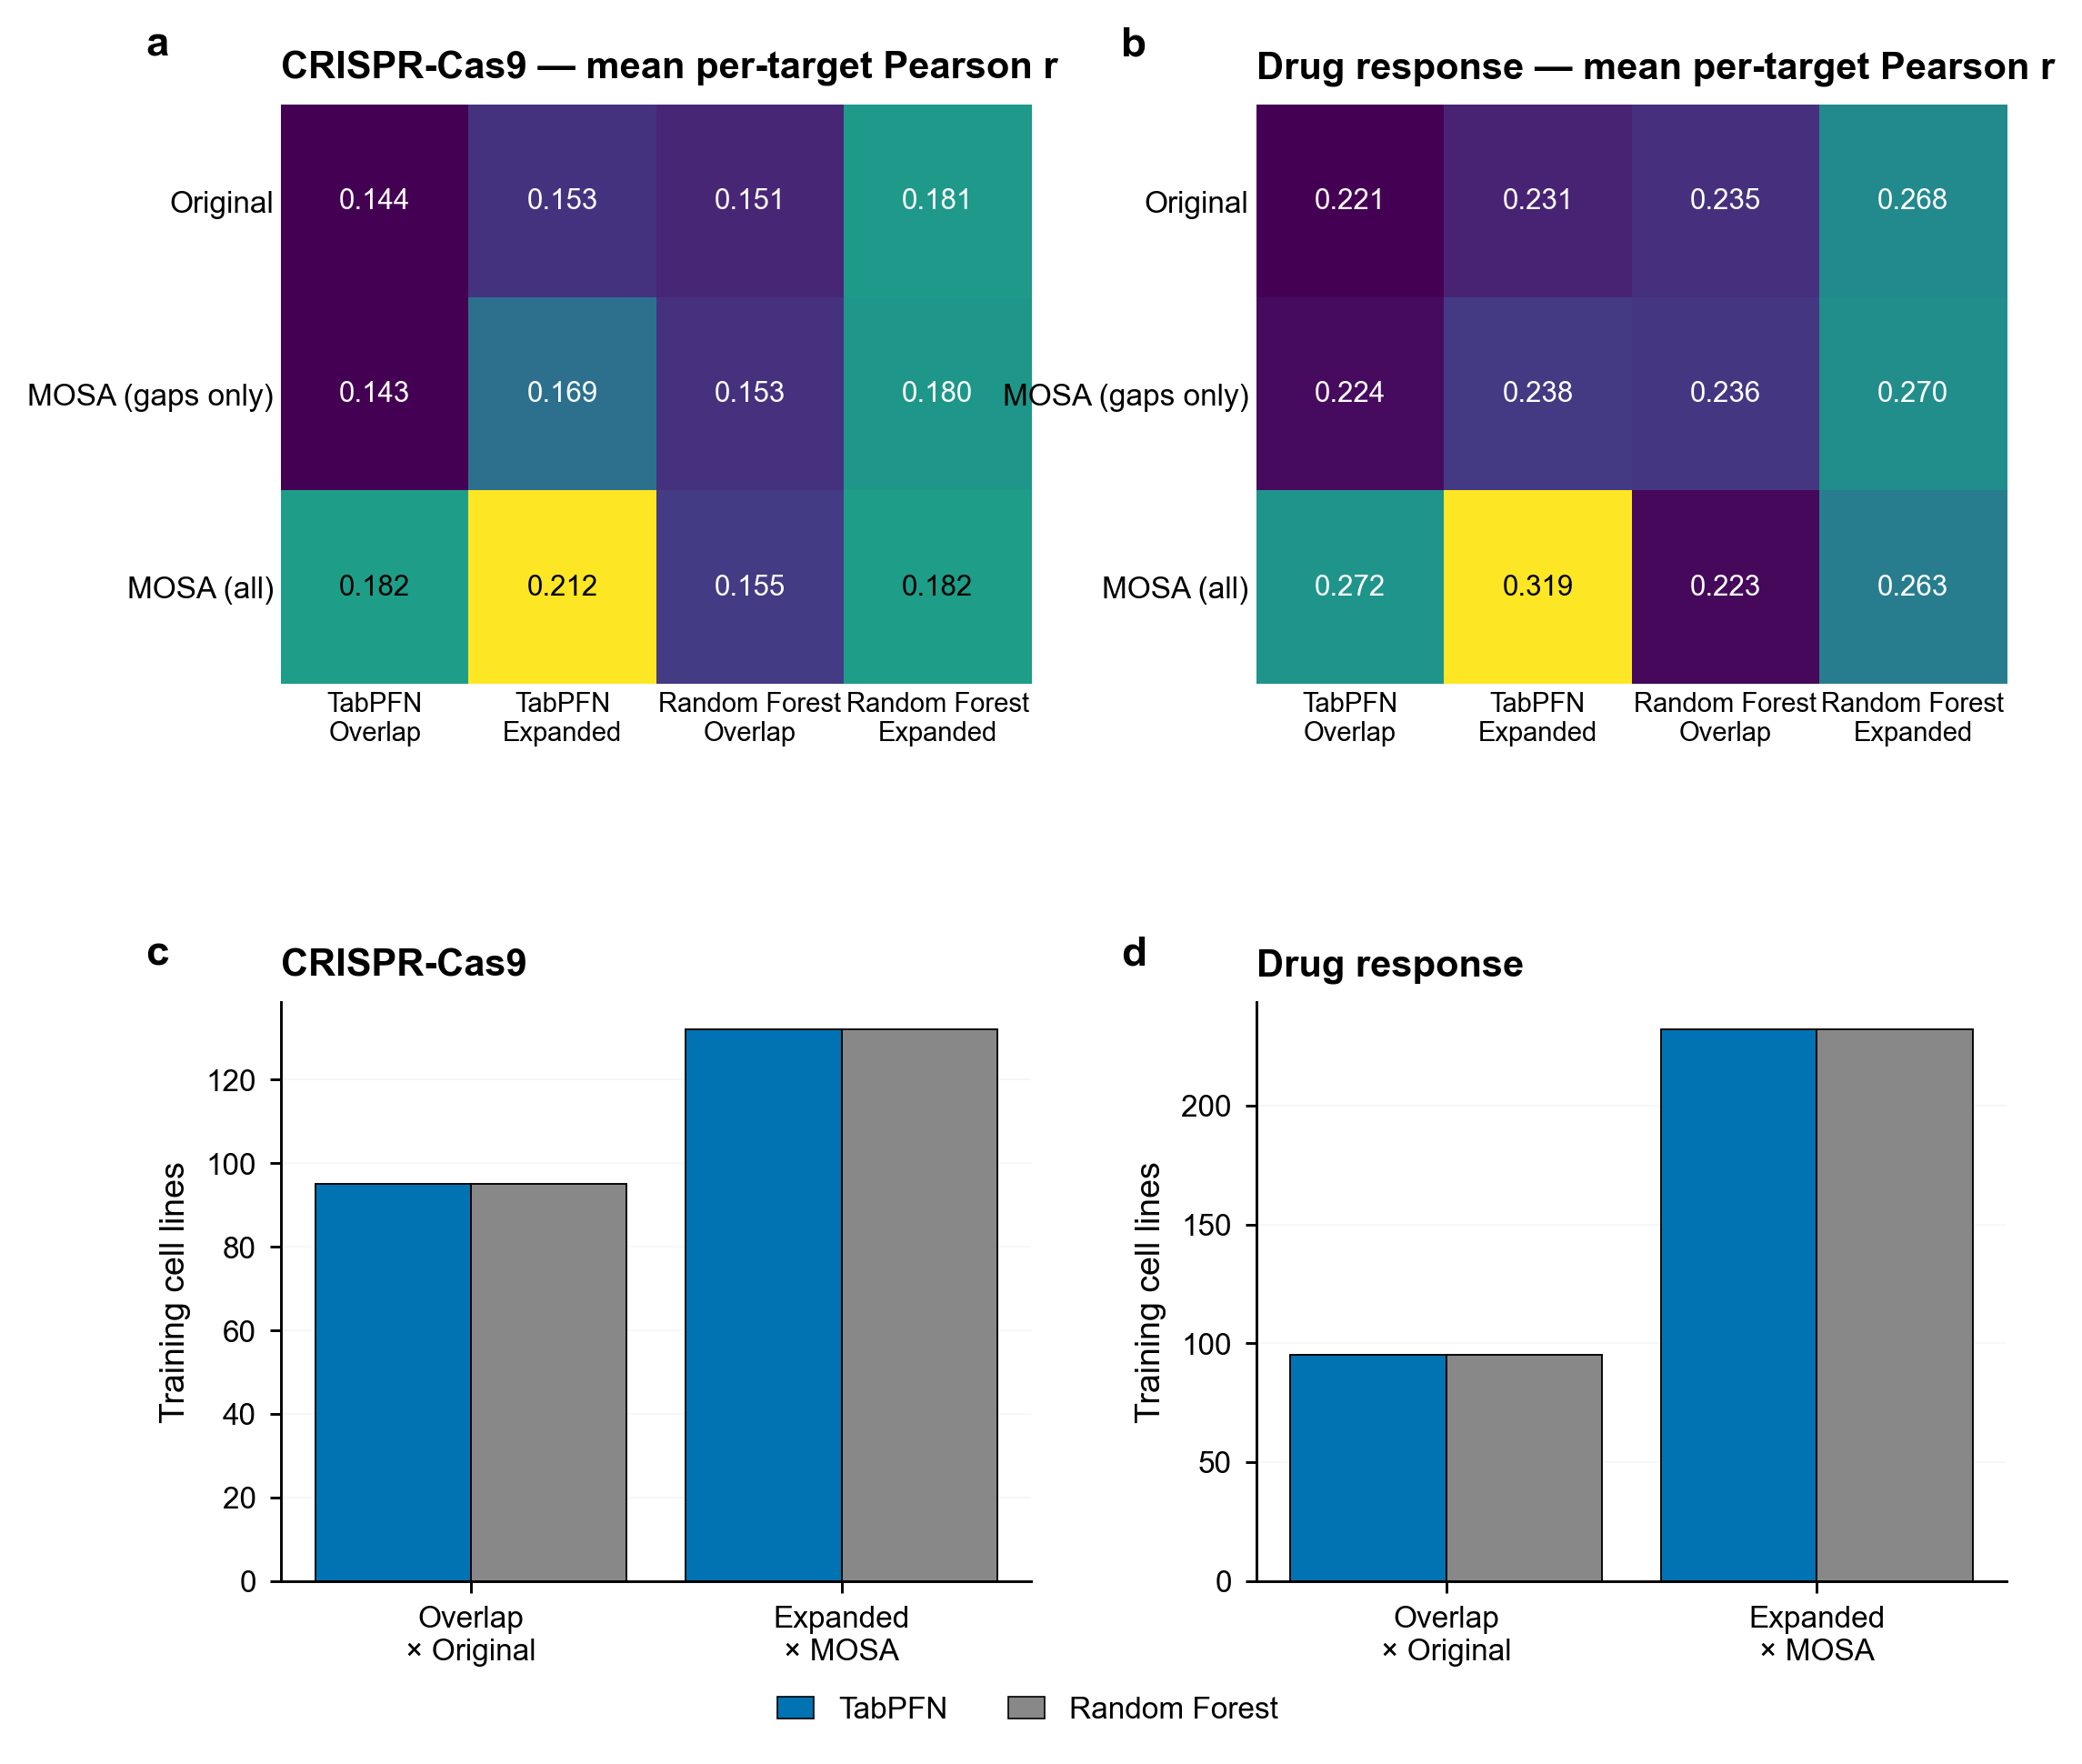

reports/cba2026_claude/prediction_analysis/20260505_131645/figP4_strategy_frame.pdf


In [7]:
p4 = pred.figP4_strategy_frame(summary_long)
display(Image(filename=str(p4.with_suffix(".png"))))
print(p4.relative_to(pred.ROOT))

## Slide-friendly singles for these four composites

Single-panel exports (column type scale) for direct slide inserts. Bar panels split per family so each takes one slide cleanly.

In [8]:
singles = [
    pred.single_figP1a_mean_r_crispr(summary_long, per_target_long),
    pred.single_figP1b_mean_r_drug(summary_long, per_target_long),
    pred.single_figP1c_pooled_crispr(summary_long, per_target_long),
    pred.single_figP1d_pooled_drug(summary_long, per_target_long),
    pred.single_figP1e_train_n_crispr(summary_long, per_target_long),
    pred.single_figP1f_train_n_drug(summary_long, per_target_long),
    pred.single_figP2a_paired_crispr(decomposed),
    pred.single_figP2b_paired_drug(decomposed),
    pred.single_figP3a_distribution(decomposed),
    pred.single_figP3b_winrate(decomposed),
    pred.single_figP4a_heatmap_crispr(summary_long),
    pred.single_figP4b_heatmap_drug(summary_long),
]
for p in singles:
    print(p.relative_to(pred.ROOT))

reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP1a_mean_r_crispr.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP1b_mean_r_drug.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP1c_pooled_crispr.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP1d_pooled_drug.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP1e_train_n_crispr.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP1f_train_n_drug.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP2a_paired_crispr.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP2b_paired_drug.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP3a_distribution.pdf
reports/cba2026_claude/prediction_analysis/20260505_131645/singles/single_figP3b_winrate.pdf
reports/cba2026_claude/

## Tables

`prediction_summary_by_condition.csv` and `prediction_wilcoxon_summary.csv` are built by `write_prediction_tables`; here we just emit them and preview.

In [9]:
table_paths = pred.write_prediction_tables(summary_long, per_target_long, decomposed)
for k, v in table_paths.items():
    print(f"{k:45s}  {v.relative_to(pred.ROOT)}")
import pandas as pd
pd.read_csv(table_paths["prediction_wilcoxon_summary"]).round(3)

prediction_summary_by_condition                reports/cba2026_claude/prediction_analysis/20260505_131645/prediction_summary_by_condition.csv
prediction_wilcoxon_summary                    reports/cba2026_claude/prediction_analysis/20260505_131645/prediction_wilcoxon_summary.csv
prediction_per_target_decomposed               reports/cba2026_claude/prediction_analysis/20260505_131645/prediction_per_target_decomposed.csv
prediction_top_gainers                         reports/cba2026_claude/prediction_analysis/20260505_131645/prediction_top_gainers.csv
prediction_selected_target_residuals           reports/cba2026_claude/prediction_analysis/20260505_131645/prediction_selected_target_residuals.csv
prediction_imputation_scope                    reports/cba2026_claude/prediction_analysis/20260505_131645/prediction_imputation_scope.csv


,target_family,comparison,n_paired,wilcoxon_p,mean_target,mean_ref
0,crisprcas9,TabPFN+MOSA vs RF baseline,500,0.000,0.212,0.151
1,crisprcas9,RF MOSA vs RF original (expanded),500,0.673,0.182,0.181
2,crisprcas9,TabPFN MOSA vs TabPFN original (expanded),500,0.000,0.212,0.153
3,crisprcas9,TabPFN vs RF on MOSA data,500,0.000,0.212,0.182
4,drugresponse,TabPFN+MOSA vs RF baseline,500,0.000,0.319,0.235
5,drugresponse,RF MOSA vs RF original (expanded),500,0.817,0.263,0.268
6,drugresponse,TabPFN MOSA vs TabPFN original (expanded),500,0.000,0.319,0.231
7,drugresponse,TabPFN vs RF on MOSA data,500,0.000,0.319,0.263
